# Analitica de Datos — Universidad de San Andres
## Clase 01: Exploracion, Manipulacion y Visualizacion

**Otoño 2026 · Negocios Digitales**

---

### Agenda

| # | Seccion | Temas |
|---|---|---|
| 1 | Setup | Instalacion e imports |
| 2 | Carga y primer vistazo | `read_csv`, `head`, `tail`, `shape` |
| 3 | Tipos y estadísticas | `info`, `describe`, `value_counts` |
| 4 | Calidad del dato | Nulos, duplicados, limpieza |
| 5 | Manipulacion | Filtros, columnas nuevas, ordenamiento, groupby |
| 6 | Visualizacion | Countplot, histograma, boxplot, scatter, heatmap |

---

> Las celdas `[DOC]` son soporte docente — respuestas y notas para el profesor.

---
## 1. Setup

In [4]:
!pip install pandas matplotlib seaborn --quiet

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')

---
## 2. Carga y primer vistazo

**Dataset:** 101 startups de IA con datos reales (Crunchbase / TechCrunch / PitchBook, 2024-2025).
Empresas como OpenAI, Anthropic, xAI, DeepSeek, Mistral, Cursor, Canva, Waymo, Figure AI y mas.

| Columna | Descripcion |
|---|---|
| `startup` | Nombre de la empresa |
| `pais` | Pais de origen |
| `anio_fundacion` | Año de fundacion |
| `sector` | Categoria (LLM, Robotica, Coding AI...) |
| `ultima_ronda` | Etapa de la ultima ronda (Seed, Serie A/B/C...) |
| `monto_ronda_usd_mm` | Monto levantado en la ultima ronda (USD millones) |
| `valuacion_usd_mm` | Valuacion al momento de esa ronda (USD millones) |
| `empleados` | Cantidad de empleados |
| `inversores_clave` | Principales inversores |

In [6]:
df = pd.read_csv('startups.csv', index_col=0)

In [7]:
# Primeras 5 filas
df.head()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
0,Weights AI,USA,2023,Plataforma ML,Seed,25.0,NaN,30,Sequoia Scout
1,Replit,USA,2016,Coding AI,Serie B,97.0,1160.0,200,"Andreessen Horowitz, Sequoia, Google"
2,Etched,USA,2022,AI Hardware / Chips,Seed,120.0,NaN,50,"Primary Venture, Y Combinator"
3,Magic AI,USA,2023,Coding AI,Serie C,320.0,NaN,100,"CapitalG, Sequoia, Jane Street"
4,Wiz,Israel,2020,Cybersecurity AI,Serie E,1000.0,12000.0,1800,"Sequoia, Andreessen Horowitz, Index Ventures"


In [8]:
# Ultimas 5 filas
df.tail()

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
111,Skild AI,USA,2023,Robotica,Serie A,300.0,1500.0,80,"Lightspeed, Coatue, Bezos Expeditions"
112,Duolingo,USA,2011,Edtech AI,Publica,NaN,12000.0,1000,Publica (NASDAQ: DUOL)
113,Together AI,USA,2022,Infraestructura Cloud,Serie B,305.0,3300.0,200,"Salesforce Ventures, Kleiner Perkins"
114,Synthell,USA,2022,Edtech AI,Seed,5.0,NaN,20,Y Combinator
115,Isomorphic Labs,UK,2021,Biotech AI,Serie A,600.0,3000.0,200,"Alphabet, Foresite Capital"


In [9]:
# (filas, columnas)
df.shape

(116, 9)

In [10]:
# Nombres de las columnas
df.columns.tolist()

['startup',
 'pais',
 'anio_fundacion',
 'sector',
 'ultima_ronda',
 'monto_ronda_usd_mm',
 'valuacion_usd_mm',
 'empleados',
 'inversores_clave']

**[DOC]**
El dataset tiene filas duplicadas a proposito — las vamos a detectar y limpiar en la seccion 4.
`shape` devuelve una tupla: `shape[0]` = filas, `shape[1]` = columnas.

---
## 3. Tipos de dato y estadísticas

In [11]:
# Tipo de dato de cada columna + cuantos valores no son nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   startup             116 non-null    str    
 1   pais                116 non-null    str    
 2   anio_fundacion      116 non-null    int64  
 3   sector              116 non-null    str    
 4   ultima_ronda        116 non-null    str    
 5   monto_ronda_usd_mm  104 non-null    float64
 6   valuacion_usd_mm    85 non-null     float64
 7   empleados           116 non-null    int64  
 8   inversores_clave    116 non-null    str    
dtypes: float64(2), int64(2), str(5)
memory usage: 15.6 KB


In [12]:
# Estadisticas descriptivas de columnas numericas
df.describe().round(1)

,anio_fundacion,monto_ronda_usd_mm,valuacion_usd_mm,empleados
count,116.0,104.0,85.0,116.0
mean,2018.9,740.4,14743.8,654.2
std,3.9,1555.4,46246.8,1004.3
min,2008.0,3.0,200.0,15.0
25%,2016.0,100.0,1250.0,150.0
50%,2019.0,231.0,3000.0,250.0
75%,2022.0,648.8,10000.0,625.0
max,2024.0,10000.0,300000.0,6000.0


**[DOC] — que señalar en describe()**

`monto_ronda_usd_mm`: media ~USD 740M vs mediana ~USD 231M. Pocas mega-rondas (OpenAI 6.600M, xAI 6.000M, Databricks 10.000M) jalan el promedio hacia arriba. La mediana es el numero honesto.

`valuacion_usd_mm`: media ~USD 14.700M vs mediana ~USD 3.000M — OpenAI (USD 300.000M) es un outlier enorme que distorsiona completamente el promedio.

`empleados`: media 654 vs mediana 250 — mismo patron. Databricks (6.000) y Waymo (4.000) jalan la media.

**Tipos de dato:** `int64` = entero · `float64` = decimal · `object` = texto

In [13]:
# Distribucion de sectores
df['sector'].value_counts()

sector
LLM / Foundation Models    23
Robotica                   10
Plataforma ML               8
Coding AI                   7
Imagen / Generativa         7
Cybersecurity AI            6
Healthtech AI               6
Edtech AI                   6
AI Hardware / Chips         5
Infraestructura Cloud       5
Biotech AI                  5
Agentes AI                  4
Legal AI                    4
Enterprise Search           3
Enterprise AI               3
Vehiculos Autonomos         3
Audio / Voz                 3
Diseño / Productividad      3
Data & Analytics            3
Busqueda / Agentes          1
Defensa / Robotica          1
Name: count, dtype: int64

In [14]:
# Distribucion de paises
df['pais'].value_counts()

pais
USA             83
UK               7
Israel           6
China            6
Canada           3
Noruega          2
Francia          2
Australia        2
Alemania         1
Paises Bajos     1
Hong Kong        1
Suecia           1
Japon            1
Name: count, dtype: int64

In [15]:
# Distribucion de etapas de ronda
df['ultima_ronda'].value_counts()

ultima_ronda
Serie C      25
Serie B      23
Serie A      19
Serie D      15
Seed         12
Publica       9
Serie E       7
Serie F       3
Sin ronda     2
Serie J       1
Name: count, dtype: int64

**[DOC]**
`value_counts()` ordena de mayor a menor automaticamente. Util para detectar desbalance entre categorias y errores de tipeo ("Serie a" vs "Serie A").

---
## 4. Calidad del dato — nulos y duplicados

In [16]:
# Cuantos nulos hay por columna
df.isnull().sum()

startup                0
pais                   0
anio_fundacion         0
sector                 0
ultima_ronda           0
monto_ronda_usd_mm    12
valuacion_usd_mm      31
empleados              0
inversores_clave       0
dtype: int64

In [17]:
# Lo mismo pero en porcentaje
(df.isnull().sum() / len(df) * 100).round(1)

startup                0.0
pais                   0.0
anio_fundacion         0.0
sector                 0.0
ultima_ronda           0.0
monto_ronda_usd_mm    10.3
valuacion_usd_mm      26.7
empleados              0.0
inversores_clave       0.0
dtype: float64

**[DOC] — por que hay nulos?**

`valuacion_usd_mm` (~27%): DeepSeek es autofinanciada, algunas startups no divulgan valuacion publica.
`monto_ronda_usd_mm` (~10%): Midjourney nunca levanto ronda externa, empresas publicas no reportan monto reciente.

Estos nulos son **datos faltantes reales**, no errores del dataset. Seaborn los ignora automaticamente en los graficos.

In [18]:
# Ver filas que tienen nulo en valuacion
df[df['valuacion_usd_mm'].isnull()][['startup', 'pais', 'sector', 'ultima_ronda']].head(10)

,startup,pais,sector,ultima_ronda
0,Weights AI,USA,Plataforma ML,Seed
2,Etched,USA,AI Hardware / Chips,Seed
3,Magic AI,USA,Coding AI,Serie C
5,Qdrant,Alemania,Plataforma ML,Serie B
7,Tabnine,Israel,Coding AI,Serie C
8,Apptronik,USA,Robotica,Serie A
10,DeepSeek,China,LLM / Foundation Models,Seed
14,Modal,USA,Infraestructura Cloud,Serie B
17,D-ID,Israel,Imagen / Generativa,Serie B
23,Khanmigo / Khan Academy,USA,Edtech AI,Sin ronda


In [19]:
# Cuantas filas duplicadas hay
df.duplicated().sum()

15

In [20]:
# Ver los duplicados (keep=False muestra TODAS las ocurrencias)
df[df.duplicated(keep=False)].sort_values('startup').head(10)

,startup,pais,anio_fundacion,sector,ultima_ronda,monto_ronda_usd_mm,valuacion_usd_mm,empleados,inversores_clave
36,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
65,1X Technologies,Noruega,2014,Robotica,Serie B,100.0,NaN,200,"OpenAI, EQT Ventures"
8,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
48,Apptronik,USA,2016,Robotica,Serie A,350.0,NaN,250,"Google, Capital Factory"
83,Covariant,USA,2017,Robotica,Serie C,222.0,2000.0,200,"Index Ventures, Tiger Global"
95,Covariant,USA,2017,Robotica,Serie C,222.0,2000.0,200,"Index Ventures, Tiger Global"
9,Darktrace,UK,2013,Cybersecurity AI,Publica,NaN,2500.0,2400,Publica (DARK.L)
92,Darktrace,UK,2013,Cybersecurity AI,Publica,NaN,2500.0,2400,Publica (DARK.L)
10,DeepSeek,China,2023,LLM / Foundation Models,Seed,700.0,NaN,200,High-Flyer Quant (autofinanciada)
64,DeepSeek,China,2023,LLM / Foundation Models,Seed,700.0,NaN,200,High-Flyer Quant (autofinanciada)


In [21]:
# Eliminar duplicados — conservar la primera ocurrencia
df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Antes : {len(df)} filas")
print(f"Despues: {len(df_clean)} filas")

Antes : 116 filas
Despues: 101 filas


**[DOC]**
`keep='first'` conserva la primera ocurrencia de cada fila duplicada y elimina las siguientes.
`reset_index(drop=True)` reinicia el indice desde 0 para que quede limpio.

A partir de aca trabajamos siempre con `df_clean`.

---
## 5. Manipulacion

### 5.1 Seleccionar columnas y filas

In [22]:
# Seleccionar una columna
df_clean['startup'].head(10)

0       Weights AI
1           Replit
2           Etched
3         Magic AI
4              Wiz
5           Qdrant
6    Perplexity AI
7          Tabnine
8        Apptronik
9        Darktrace
Name: startup, dtype: str

In [23]:
# Seleccionar multiples columnas
df_clean[['startup', 'sector', 'valuacion_usd_mm']].head(10)

,startup,sector,valuacion_usd_mm
0,Weights AI,Plataforma ML,NaN
1,Replit,Coding AI,1160.0
2,Etched,AI Hardware / Chips,NaN
3,Magic AI,Coding AI,NaN
4,Wiz,Cybersecurity AI,12000.0
5,Qdrant,Plataforma ML,NaN
6,Perplexity AI,Busqueda / Agentes,9000.0
7,Tabnine,Coding AI,NaN
8,Apptronik,Robotica,NaN
9,Darktrace,Cybersecurity AI,2500.0


In [24]:
# Filtrar filas: solo startups de USA
df_usa = df_clean[df_clean['pais'] == 'USA']
print(f"Startups de USA: {len(df_usa)}")
df_usa[['startup', 'sector', 'valuacion_usd_mm']].head(8)

Startups de USA: 72


,startup,sector,valuacion_usd_mm
0,Weights AI,Plataforma ML,NaN
1,Replit,Coding AI,1160.0
2,Etched,AI Hardware / Chips,NaN
3,Magic AI,Coding AI,NaN
6,Perplexity AI,Busqueda / Agentes,9000.0
8,Apptronik,Robotica,NaN
11,Spring Health,Healthtech AI,7500.0
13,Hebbia,Enterprise Search,700.0


In [25]:
# Filtrar con condicion numerica: valuacion mayor a USD 10.000M
df_clean[df_clean['valuacion_usd_mm'] > 10000][['startup', 'pais', 'valuacion_usd_mm']].sort_values('valuacion_usd_mm', ascending=False)

,startup,pais,valuacion_usd_mm
85,OpenAI,USA,300000.0
83,Databricks,USA,62000.0
64,Anthropic,USA,60000.0
36,xAI,USA,50000.0
90,Waymo,USA,45000.0
50,Canva,Australia,42000.0
82,Cursor / Anysphere,USA,29300.0
56,Samsara,USA,20000.0
76,CoreWeave,USA,19000.0
77,Tempus AI,USA,16000.0


In [26]:
# Condicion multiple: USA + valuacion conocida
df_clean[(df_clean['pais'] == 'USA') & (df_clean['valuacion_usd_mm'].notna())][['startup', 'sector', 'valuacion_usd_mm']].head(8)

,startup,sector,valuacion_usd_mm
1,Replit,Coding AI,1160.0
6,Perplexity AI,Busqueda / Agentes,9000.0
11,Spring Health,Healthtech AI,7500.0
13,Hebbia,Enterprise Search,700.0
15,World Labs,LLM / Foundation Models,1000.0
16,Physical Intelligence,Robotica,2000.0
18,Writer,Enterprise AI,1900.0
19,Nuro,Vehiculos Autonomos,8600.0


In [27]:
# Filtrar con lista de valores — isin()
paises_latam = ['Argentina', 'Brasil', 'Mexico', 'Colombia', 'Chile']
df_clean[df_clean['pais'].isin(paises_latam)][['startup', 'pais', 'sector']]

,startup,pais,sector


**[DOC]**
`&` = AND, `|` = OR. Cada condicion debe ir entre parentesis cuando se combinan.
`.notna()` = lo opuesto a `.isnull()` — selecciona filas donde el valor existe.

### 5.2 Ordenar

In [28]:
# Top 10 startups por valuacion
df_clean.sort_values('valuacion_usd_mm', ascending=False).head(10)[['startup', 'pais', 'sector', 'valuacion_usd_mm']]

,startup,pais,sector,valuacion_usd_mm
85,OpenAI,USA,LLM / Foundation Models,300000.0
83,Databricks,USA,Data & Analytics,62000.0
64,Anthropic,USA,LLM / Foundation Models,60000.0
36,xAI,USA,LLM / Foundation Models,50000.0
90,Waymo,USA,Vehiculos Autonomos,45000.0
50,Canva,Australia,Diseño / Productividad,42000.0
82,Cursor / Anysphere,USA,Coding AI,29300.0
56,Samsara,USA,Data & Analytics,20000.0
76,CoreWeave,USA,Infraestructura Cloud,19000.0
77,Tempus AI,USA,Healthtech AI,16000.0


In [29]:
# Top 10 por empleados
df_clean.sort_values('empleados', ascending=False).head(10)[['startup', 'sector', 'empleados', 'valuacion_usd_mm']]

,startup,sector,empleados,valuacion_usd_mm
83,Databricks,Data & Analytics,6000,62000.0
50,Canva,Diseño / Productividad,4500,42000.0
90,Waymo,Vehiculos Autonomos,4000,45000.0
56,Samsara,Data & Analytics,3200,20000.0
88,Anduril,Defensa / Robotica,3000,14000.0
85,OpenAI,LLM / Foundation Models,3000,300000.0
80,SentinelOne,Cybersecurity AI,2800,10000.0
77,Tempus AI,Healthtech AI,2400,16000.0
9,Darktrace,Cybersecurity AI,2400,2500.0
4,Wiz,Cybersecurity AI,1800,12000.0


### 5.3 Crear nuevas columnas

In [30]:
# Edad de la startup al dia de hoy
df_clean['edad_anios'] = 2025 - df_clean['anio_fundacion']
df_clean[['startup', 'anio_fundacion', 'edad_anios']].head(8)

,startup,anio_fundacion,edad_anios
0,Weights AI,2023,2
1,Replit,2016,9
2,Etched,2022,3
3,Magic AI,2023,2
4,Wiz,2020,5
5,Qdrant,2021,4
6,Perplexity AI,2022,3
7,Tabnine,2018,7


In [31]:
# Ratio valuacion / empleados — cuanto "vale" cada empleado en USD mm
df_clean['valuacion_por_empleado'] = (df_clean['valuacion_usd_mm'] / df_clean['empleados']).round(1)

df_clean.sort_values('valuacion_por_empleado', ascending=False)[['startup', 'empleados', 'valuacion_usd_mm', 'valuacion_por_empleado']].head(10)

,startup,empleados,valuacion_usd_mm,valuacion_por_empleado
53,Thinking Machines,100,12000.0,120.0
41,Safe Superintelligence,50,5000.0,100.0
94,Mercor,100,10000.0,100.0
85,OpenAI,3000,300000.0,100.0
82,Cursor / Anysphere,500,29300.0,58.6
36,xAI,900,50000.0,55.6
61,Reflection AI,150,8000.0,53.3
20,Cognition AI,200,10200.0,51.0
64,Anthropic,1300,60000.0,46.2
15,World Labs,30,1000.0,33.3


**[DOC]**
Crear columnas nuevas es una de las operaciones mas comunes en pandas. La formula se aplica fila por fila automaticamente — no hay que escribir un loop.

`valuacion_por_empleado` altisima = empresa muy valiosa con poco personal (ej: Midjourney, DeepSeek). Cuestion para debatir: es sostenible?

### 5.4 Groupby — resumir por grupos

In [32]:
# Promedio de valuacion por sector
df_clean.groupby('sector')['valuacion_usd_mm'].mean().round(1).sort_values(ascending=False)

sector
LLM / Foundation Models    33346.4
Data & Analytics           32000.0
Diseño / Productividad     22666.7
Vehiculos Autonomos        19533.3
Defensa / Robotica         14000.0
Busqueda / Agentes          9000.0
Coding AI                   8577.4
Infraestructura Cloud       7933.3
Edtech AI                   6500.0
Cybersecurity AI            6280.0
Healthtech AI               5238.0
Legal AI                    5000.0
Agentes AI                  4125.0
AI Hardware / Chips         3166.7
Enterprise Search           2600.0
Robotica                    2025.0
Biotech AI                  2000.0
Audio / Voz                 1900.0
Enterprise AI               1700.0
Plataforma ML               1440.0
Imagen / Generativa         1000.0
Name: valuacion_usd_mm, dtype: float64

In [33]:
# Resumen completo por sector
resumen_sector = df_clean.groupby('sector').agg(
    cantidad     = ('startup',         'count'),
    valuacion_md = ('valuacion_usd_mm', 'median'),
    monto_md     = ('monto_ronda_usd_mm','median'),
    empleados_md = ('empleados',        'median'),
).round(1).sort_values('cantidad', ascending=False)

resumen_sector

,cantidad,valuacion_md,monto_md,empleados_md
sector,,,,
LLM / Foundation Models,18,5250.0,850.0,200.0
Robotica,7,2000.0,300.0,200.0
Plataforma ML,7,750.0,50.0,200.0
Coding AI,7,1250.0,227.0,200.0
Healthtech AI,6,1640.0,110.0,250.0
Imagen / Generativa,6,1000.0,90.0,150.0
Biotech AI,5,2000.0,382.5,300.0
Cybersecurity AI,5,5100.0,550.0,1800.0
Infraestructura Cloud,5,3300.0,305.0,200.0


In [34]:
# Cuantas startups hay por pais
df_clean.groupby('pais')['startup'].count().sort_values(ascending=False)

pais
USA             72
Israel           6
China            5
UK               5
Canada           3
Australia        2
Francia          2
Alemania         1
Hong Kong        1
Japon            1
Noruega          1
Paises Bajos     1
Suecia           1
Name: startup, dtype: int64

In [35]:
# Resumen por etapa de ronda
df_clean.groupby('ultima_ronda').agg(
    cantidad     = ('startup',          'count'),
    valuacion_md = ('valuacion_usd_mm',  'median'),
    monto_md     = ('monto_ronda_usd_mm','median'),
).round(1)

,cantidad,valuacion_md,monto_md
ultima_ronda,,,
Publica,7,12000.0,NaN
Seed,9,6500.0,65.0
Serie A,17,1500.0,250.0
Serie B,21,1160.0,130.0
Serie C,23,1850.0,222.0
Serie D,14,5100.0,285.0
Serie E,5,12000.0,1000.0
Serie F,3,14000.0,1000.0
Serie J,1,62000.0,10000.0


**[DOC]**
`groupby` + `agg` es una de las combinaciones mas poderosas de pandas.
`count` = cuantos hay · `mean` = promedio · `median` = mediana · `max` = maximo · `min` = minimo

La mediana es mas robusta que la media cuando hay outliers — que es exactamente el caso de valuaciones de startups.

---
## 6. Visualizacion

> Antes de cada grafico: **que pregunta de negocio estoy respondiendo?**

| Pregunta | Grafico |
|---|---|
| Cuantos hay por categoria? | `countplot` |
| Como se distribuye una variable? | `histplot` |
| Como varia la distribucion entre grupos? | `boxplot` |
| Se relacionan dos variables numericas? | `scatterplot / lmplot` |
| Que variables se mueven juntas? | `heatmap` |
| Top N valores? | `barh` horizontal |

In [36]:
# Paleta de colores por sector — consistencia visual en todos los graficos
sector_palette = {
    'LLM / Foundation Models': '#4C72B0',
    'Coding AI':                '#DD8452',
    'Robotica':                 '#55A868',
    'Imagen / Generativa':      '#C44E52',
    'Healthtech AI':            '#8172B2',
    'Cybersecurity AI':         '#937860',
    'Plataforma ML':            '#DA8BC3',
    'AI Hardware / Chips':      '#8C8C8C',
    'Infraestructura Cloud':    '#CCB974',
    'Data & Analytics':         '#64B5CD',
    'Biotech AI':               '#A2C8EC',
    'Edtech AI':                '#FFBE7D',
    'Agentes AI':               '#D4E6B5',
    'Enterprise AI':            '#B7C9E2',
    'Legal AI':                 '#F7C6C7',
    'Imagen / Generativa':      '#C44E52',
    'Vehiculos Autonomos':      '#5F9EA0',
    'Diseño / Productividad':   '#E8A838',
    'Audio / Voz':              '#B85C38',
}

In [38]:
# Paleta automatica de colores por sector
sectores = df_clean['sector'].unique()
colores  = sns.color_palette('tab20', n_colors=len(sectores))
sector_palette = dict(zip(sectores, colores))

### 6.1 Countplot — distribucion por categoria

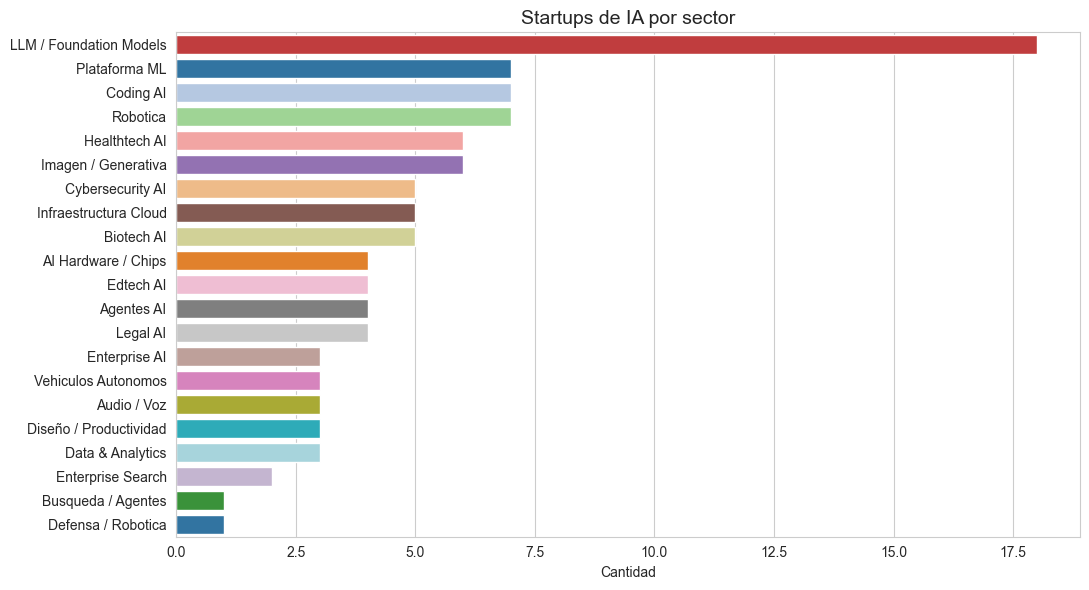

In [39]:
# Startups por sector — horizontal para labels largos
orden = df_clean['sector'].value_counts().index

plt.figure(figsize=(11, 6))
sns.countplot(data=df_clean, y='sector', order=orden,
              hue='sector', palette=sector_palette, legend=False)
plt.title('Startups de IA por sector', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 paises
orden_paises = df_clean['pais'].value_counts().head(10).index

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean[df_clean['pais'].isin(orden_paises)],
              y='pais', order=orden_paises,
              hue='pais', palette='viridis', legend=False)
plt.title('Top 10 paises por cantidad de startups', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('')
plt.tight_layout()
plt.show()

**[DOC]**
USA domina ampliamente — casi el 80% del dataset. UK, Israel y China son los unicos competidores relevantes.

`hue='sector'` + `legend=False` permite asignar un color distinto a cada barra sin mostrar leyenda. Util cuando el eje Y ya identifica cada categoria.

### 6.2 Histograma — distribucion de variables numericas

In [ ]:
# Distribucion del monto de la ultima ronda
plt.figure(figsize=(11, 5))
sns.histplot(df_clean.dropna(subset=['monto_ronda_usd_mm']),
             x='monto_ronda_usd_mm', bins=25, kde=True, color='steelblue')

media   = df_clean['monto_ronda_usd_mm'].mean()
mediana = df_clean['monto_ronda_usd_mm'].median()

plt.axvline(media,   color='red',   linestyle='--', label=f'Media:   USD {media:,.0f}M')
plt.axvline(mediana, color='black', linestyle='--', label=f'Mediana: USD {mediana:,.0f}M')

plt.title('Distribucion del monto de ronda', fontsize=14)
plt.xlabel('Monto (USD millones)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Distribucion de empleados — comparando B2B vs autofinanciadas
plt.figure(figsize=(11, 5))
sns.histplot(df_clean, x='empleados', bins=30, kde=True, color='steelblue')
plt.axvline(df_clean['empleados'].median(), color='black', linestyle='--',
            label=f"Mediana: {df_clean['empleados'].median():.0f} empleados")
plt.title('Distribucion de empleados — AI Startups', fontsize=14)
plt.xlabel('Empleados')
plt.legend()
plt.tight_layout()
plt.show()

**[DOC]**
Ambas distribuciones muestran el mismo patron: sesgo a la derecha. La gran mayoria de startups son pequenas, pero unos pocos gigantes (Databricks 6.000 empleados, Waymo 4.000) estiran la cola.

`kde=True` dibuja la curva de densidad suavizada — muestra la "forma" de la distribucion mas alla de los bins.

### 6.3 Boxplot — distribucion entre grupos

In [ ]:
# Monto de ronda por etapa
orden_rondas = ['Seed', 'Serie A', 'Serie B', 'Serie C', 'Serie D', 'Serie E', 'Serie F', 'Serie J']
rondas_ok = [r for r in orden_rondas if r in df_clean['ultima_ronda'].values]

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x='ultima_ronda', y='monto_ronda_usd_mm',
            order=rondas_ok, palette='Blues')
plt.title('Monto de ronda por etapa', fontsize=14)
plt.xlabel('Etapa de ronda')
plt.ylabel('Monto (USD millones)')
plt.tight_layout()
plt.show()

In [ ]:
# Empleados por sector — top 8 sectores
top_sectores = df_clean['sector'].value_counts().head(8).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[df_clean['sector'].isin(top_sectores)],
            x='empleados', y='sector',
            order=df_clean[df_clean['sector'].isin(top_sectores)].groupby('sector')['empleados'].median().sort_values(ascending=False).index,
            palette='Blues')
plt.title('Distribucion de empleados por sector', fontsize=14)
plt.xlabel('Empleados')
plt.ylabel('')
plt.tight_layout()
plt.show()

**[DOC]**
El boxplot muestra mediana, cuartiles, rango y outliers de un vistazo. Un barplot del promedio ocultaria todo eso.

Pregunta: por que Serie E tiene outliers tan extremos? Porque OpenAI (6.600M) esta en Serie E. Con el boxplot se ve inmediatamente que es un valor atipico, no la norma de esa etapa.

### 6.4 Scatter plot — relacion entre dos variables

In [ ]:
# Relacion entre monto de ronda y valuacion
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.dropna(subset=['monto_ronda_usd_mm', 'valuacion_usd_mm']),
                x='monto_ronda_usd_mm', y='valuacion_usd_mm',
                hue='sector', palette=sector_palette, s=80, alpha=0.8)
plt.title('Monto de ronda vs Valuacion', fontsize=14)
plt.xlabel('Monto ultima ronda (USD millones)')
plt.ylabel('Valuacion (USD millones)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Mismo scatter con linea de regresion — lmplot
sns.lmplot(data=df_clean.dropna(subset=['monto_ronda_usd_mm', 'valuacion_usd_mm']),
           x='monto_ronda_usd_mm', y='valuacion_usd_mm',
           height=6, aspect=1.5,
           scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'})
plt.title('Monto vs Valuacion — con linea de regresion', fontsize=13)
plt.xlabel('Monto ultima ronda (USD millones)')
plt.ylabel('Valuacion (USD millones)')
plt.tight_layout()
plt.show()

In [ ]:
# Scatter coloreado por etapa de ronda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean.dropna(subset=['monto_ronda_usd_mm', 'valuacion_usd_mm']),
                x='empleados', y='valuacion_usd_mm',
                hue='ultima_ronda', palette='Set2', s=80, alpha=0.8)
plt.title('Empleados vs Valuacion por etapa', fontsize=14)
plt.xlabel('Empleados')
plt.ylabel('Valuacion (USD millones)')
plt.legend(title='Ronda')
plt.tight_layout()
plt.show()

**[DOC]**
`scatterplot` = puntos sin linea. `lmplot` = scatter + regresion lineal automatica.

La linea de regresion muestra la tendencia general. Si los puntos estan muy dispersos alrededor de la linea, la correlacion es debil.

La diferencia entre `sns.scatterplot` y `sns.lmplot`: el primero es una funcion de axes-level (va dentro de `plt.figure`), el segundo es figure-level (crea su propia figura).

### 6.5 Top N — barras horizontales

In [ ]:
# Top 10 startups por valuacion
top10 = df_clean.dropna(subset=['valuacion_usd_mm']).sort_values('valuacion_usd_mm', ascending=False).head(10)

plt.figure(figsize=(11, 6))
colores = sns.color_palette('flare', n_colors=10)
bars = plt.barh(top10['startup'][::-1], top10['valuacion_usd_mm'][::-1], color=colores)

# Etiqueta con el valor al final de cada barra
for bar in bars:
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
             f"USD {bar.get_width():,.0f}M",
             va='center', fontsize=9)

plt.title('Top 10 startups por valuacion (USD millones)', fontsize=14)
plt.xlabel('Valuacion (USD millones)')
plt.xlim(0, top10['valuacion_usd_mm'].max() * 1.25)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 startups por empleados
top10_emp = df_clean.sort_values('empleados', ascending=False).head(10)

plt.figure(figsize=(11, 6))
colores = sns.color_palette('crest', n_colors=10)
bars = plt.barh(top10_emp['startup'][::-1], top10_emp['empleados'][::-1], color=colores)

for bar in bars:
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f"{int(bar.get_width()):,}", va='center', fontsize=9)

plt.title('Top 10 startups por empleados', fontsize=14)
plt.xlabel('Empleados')
plt.xlim(0, top10_emp['empleados'].max() * 1.2)
plt.tight_layout()
plt.show()

**[DOC]**
`[::-1]` invierte el orden para que la barra mas larga quede arriba.
`plt.text()` escribe el valor al final de cada barra — hace que el grafico sea mas legible sin necesidad de leer el eje X.

`plt.barh` = matplotlib directo. `sns.barplot` hace lo mismo con menos codigo pero menos control de personalizacion.

### 6.6 Heatmap — correlaciones

In [ ]:
# Calcular matriz de correlacion
cols = ['anio_fundacion', 'monto_ronda_usd_mm', 'valuacion_usd_mm', 'empleados', 'edad_anios']
corr = df_clean[cols].corr()

# Mascara para ocultar triangulo superior (es simetrico — corr(A,B) = corr(B,A))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Matriz de Correlacion — AI Startups', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap sin mascara — para comparar
plt.figure(figsize=(8, 6))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Matriz de Correlacion — sin mascara', fontsize=14)
plt.tight_layout()
plt.show()

**[DOC]**
Diferencia entre los dos heatmaps: el primero oculta el triangulo superior porque es redundante (la correlacion es simetrica). El segundo lo muestra — util para comparar visualmente cual es mas claro.

`cmap='RdYlGn'`: rojo = negativo, amarillo = neutro, verde = positivo.
`cmap='coolwarm'`: azul = negativo, rojo = positivo. Muy comun en papers academicos.

`center=0` hace que el color neutro caiga exactamente en correlacion = 0.
`vmin=-1, vmax=1` usa la escala completa — sin esto el verde mas intenso aparece en el maximo del dataset aunque sea solo 0.6.

---
## Resumen

| Seccion | Funciones clave |
|---|---|
| Carga | `pd.read_csv()` · `.head()` · `.tail()` · `.shape` · `.columns` |
| Estadisticas | `.info()` · `.describe()` · `.value_counts()` |
| Calidad | `.isnull().sum()` · `.duplicated()` · `.drop_duplicates()` |
| Manipulacion | filtros `[]` · `.sort_values()` · `.isin()` · `.notna()` · nueva columna · `.groupby().agg()` |
| Visualizacion | `countplot` · `histplot` · `boxplot` · `scatterplot` · `lmplot` · `barh` · `heatmap` |

---
*Proxima clase: violin plots, line charts, analisis multivariado*